# SO(3) and SE(3)

## Overview
Understanding rotation matrices (SO(3)) and rigid body transformations (SE(3)) is fundamental to computer vision and robotics. These mathematical structures allow us to represent and compose rotations and 3D transformations in a consistent and computationally efficient way.

## 1. Frames of Reference
**Goal:** Understand the concept of reference frames and how to represent positions and orientations relative to different coordinate systems.

- **World frame** (global frame, ground frame): Fixed reference frame for the entire scene
- **Camera frame** (body frame, local frame): Moving reference frame attached to the camera or object
- **Transformation matrices** connect these frames and allow us to convert between them

In [1]:
import cv2
import numpy as np
from scipy.spatial.transform import Rotation
np.set_printoptions(suppress=True, precision=3)

## 2. Transformation of a Point

**Goal:** Learn how to transform a 3D point from one coordinate frame to another using transformation matrices. Understand the relationship between rotation matrices, translation vectors, and homogeneous 4×4 transformation matrices.

**Key Concepts:**
- Transforming a point from frame 2 to frame 1: $v_1 = T_{12} \cdot v_2$
- Homogeneous coordinates: Adding a 1 as the 4th component for 3D points
- Two approaches: separate R and t matrices vs. unified 4×4 transformation matrix
- Verification using inverse transformations

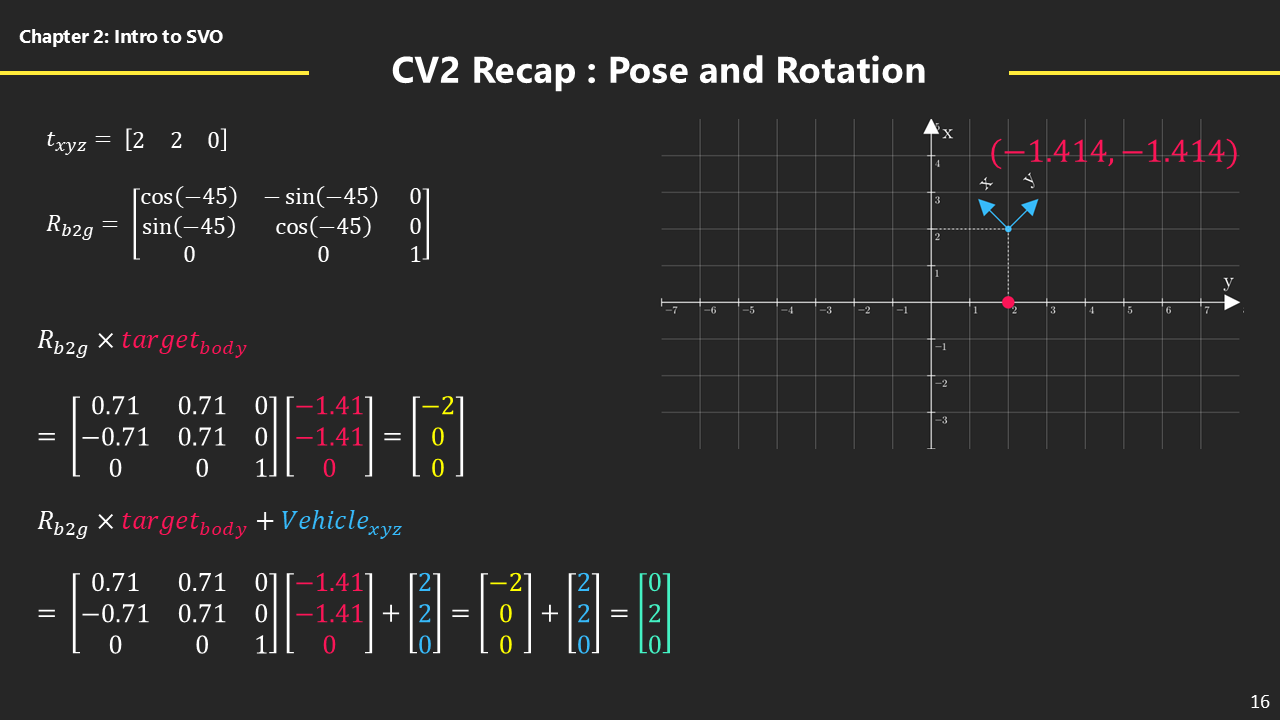

### 2.1 Let's set up the parameters

In [3]:
# Define the robot's pose as xyz vector
pose = np.array([2, 2, 0])

# Define the robot's angular orientation as rotation matrix
RotM = Rotation.from_euler('zyx', [-45, 0, 0], degrees=True).as_matrix()


# Define a measurement in the robot's body frame
meas_body = np.array([-1.4, -1.4, 0]).T

# Display robot pose
print("Rotation matrix:")
print(RotM)
print("\ntranslation:")
print(pose)
print("\nMeasurement in robot body frame:")
print(meas_body)

Rotation matrix:
[[ 0.707  0.707  0.   ]
 [-0.707  0.707 -0.   ]
 [-0.     0.     1.   ]]

translation:
[2 2 0]

Measurement in robot body frame:
[-1.4 -1.4  0. ]


### 2.2 Convert a 3D vector from the body frame to the world (ground) frame

$$ v_w = R v_b + t $$

- where $v_w$ is a vector in the world frame
- where $v_b$ is a vector in the body frame

In [ ]:
# Convert measurement from body frame to world frame
world_pose = RotM @ meas_body + pose

print("World pose:")
print(world_pose)

### 2.3 Transformation Matrix Construction

**Goal:** Construct the 4x4 Transformation Matrix $T_{bw}$ from Rotation Matrix $R$ and translation $t$.

**Expected Result:**
- A 4x4 matrix where:
  - Top-left 3x3 block is the Rotation Matrix ($R$)
  - Top-right 3x1 column is the Translation Vector ($t$)
  - Bottom row is $[0, 0, 0, 1]$

In [4]:
# Construct the 4x4 Transformation Matrix
T_bw = np.eye(4)
T_bw[:3, :3] = RotM
T_bw[:3, 3] = pose

print("T_bw:")
print(T_bw)

T_bw:
[[ 0.707  0.707  0.     2.   ]
 [-0.707  0.707 -0.     2.   ]
 [-0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]


### 2.4 Apply Transformation

**Goal:** Transform a point from the body frame to the world frame using the 4x4 transformation matrix.

**Steps:**
1. Convert the 3D point to homogeneous coordinates (add a 1).
2. Perform matrix multiplication: $v_{world} = T_{bw} \cdot v_{body}$.
3. Convert back to 3D Cartesian coordinates (remove the 4th component).

In [ ]:
# Convert 3D vector to homogeneous coordinates by adding 1 at the end
vec_hg = np.hstack((meas_body, 1))

# Multiply transformation matrix T with homogeneous vector
world_pose = T_bw @ vec_hg

# Return 3D vector (not 4D)
world_pose = world_pose[:-1]

print("World pose (using T):")
print(world_pose)

### 2.5 Inverse Transformation

**Goal:** Verify the transformation by mapping the point back from world frame to body frame using the inverse matrix.

**Concept:** $v_{body} = T_{bw}^{-1} \cdot v_{world}$

In [ ]:
# Compute the inverse of transformation matrix T
T_inv = np.linalg.inv(T_bw)

# Multiply inverse transformation with world point
body_pose_again = T_inv @ np.hstack((world_pose, 1))
body_pose_again = body_pose_again[:-1]

print("Body pose (recovered):")
print(body_pose_again)
print("\nOriginal body measurement:")
print(meas_body)

## 3. Relative Motion Between Frames

**Goal:** Learn how to compute the transformation between two frames when both are known relative to a common reference frame. This is essential for calculating the relative pose between two cameras, two robots, or any two points in a multi-frame system.

**Key Concepts:**
- Chain rule for transformations: $T_{12} = T_{10} \cdot T_{02} = T_{01}^{-1} \cdot T_{02}$
- Composing transformations from multiple reference frames
- Using matrix inversion to reverse the direction of a transformation

**Visualization:**

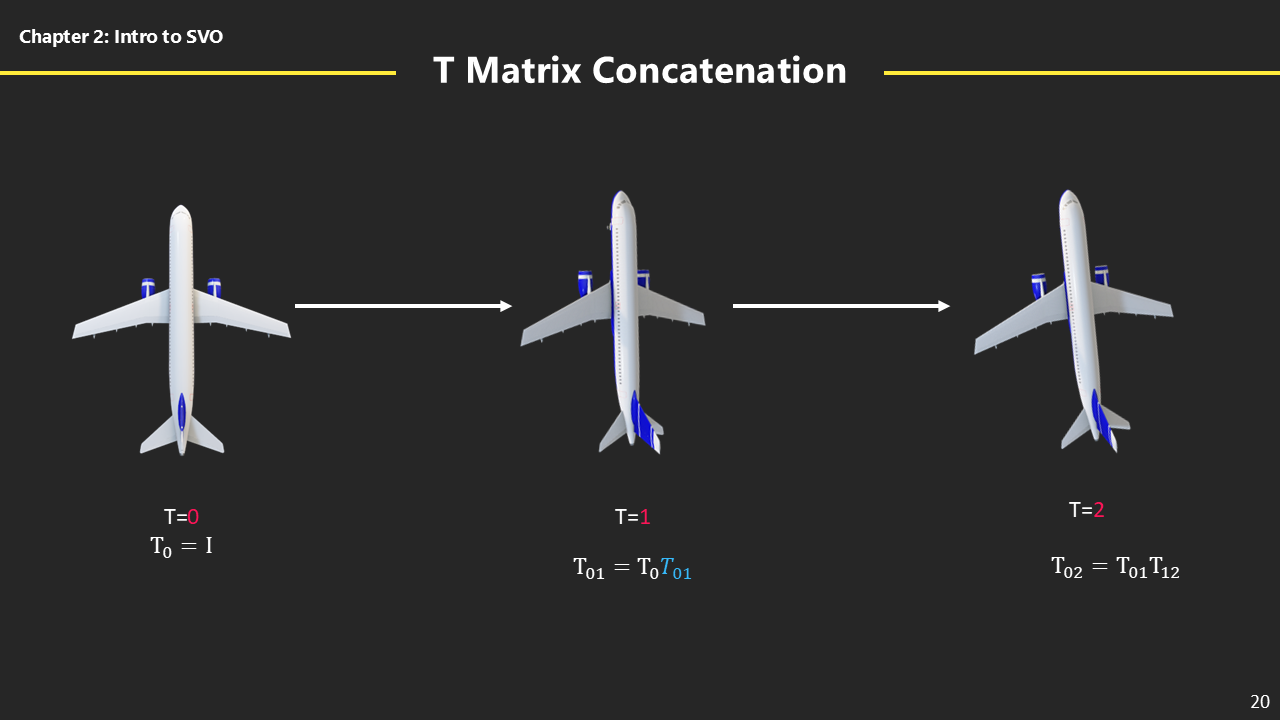
**Problem:** Given $T_{00}$, $T_{01}$, and $T_{02}$, find $T_{12}$?

In [ ]:
# Define the transformation matrices
# T 0 to 0 = Identity
T00_ex = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

# T 1 to 0 = Position of 1 relative to 0
T01 = np.array([
    [1, 0, 0, 1],
    [0, 1, 0, 2],
    [0, 0, 1, 3],
    [0, 0, 0, 1]
])

# T 2 to 0 = Position of 2 relative to 0
T02 = np.array([
    [1, 0, 0, 4],
    [0, 1, 0, 5],
    [0, 0, 1, 6],
    [0, 0, 0, 1]
])

# Compute inverse of T01
T10 = np.linalg.inv(T01)

# Compose transformations: T12 = T10 @ T02
T12 = T10 @ T02

print("T12 (relative transform from frame 1 to frame 2):")
print(T12)

## 4. SO(3) - Rotation Matrix and Angular Velocity

**Goal:** Understand how to represent rotations using rotation matrices and angular velocity vectors. Learn Rodrigues' formula for converting between rotation vectors (compact representation) and rotation matrices (standard 3×3 representation).

**Key Concepts:**
- Angular Velocity Vector: A compact 3D representation of rotation where direction = rotation axis and magnitude = rotation angle
- Rotation Matrix: A 3×3 orthogonal matrix (SO(3)) representing a pure rotation
- Rodrigues' Formula: Mathematical transformation between rotation vector and rotation matrix
- Practical conversion: Converting between vector ↔ matrix representations for efficient computation

In [6]:
r_vec = np.array([0.1, 0.2, 0.3])   # rad 

# Use cv2.Rodrigues to convert rotation vector to rotation matrix
RotM, _ = cv2.Rodrigues(r_vec)

print("Rotation vector:")
print(r_vec)
print("\nRotation matrix:")
print(RotM)

Rotation vector:
[0.1 0.2 0.3]

Rotation matrix:
[[ 0.936 -0.283  0.21 ]
 [ 0.303  0.951 -0.068]
 [-0.181  0.127  0.975]]


### 4.1 Rotation Matrix to Vector

**Goal:** Convert the 3x3 Rotation Matrix back into a Rotation Vector.

**Expected Result:**
- A 1D array of shape (3,) representing the rotation vector.
- Values should match the original `r_vec`.

In [7]:
# Use cv2.Rodrigues to convert rotation matrix back to vector
r_vec_again, _ = cv2.Rodrigues(RotM)

print("Recovered rotation vector:")
print(r_vec_again.flatten())
print("\nOriginal rotation vector:")
print(r_vec)

Recovered rotation vector:
[0.1 0.2 0.3]

Original rotation vector:
[0.1 0.2 0.3]
